<a href="https://colab.research.google.com/github/kangyeson/7th-BE-Blog/blob/main/0928/digits_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

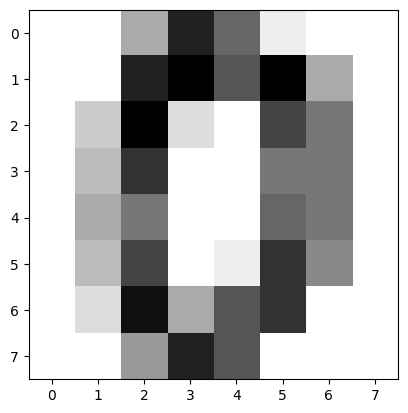

In [53]:
digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')

In [54]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=4)
X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4)

In [56]:
y_pred = knn.predict(X_test)
scores = metrics.accuracy_score(y_test, y_pred)
print(scores)

0.9833333333333333


[9]


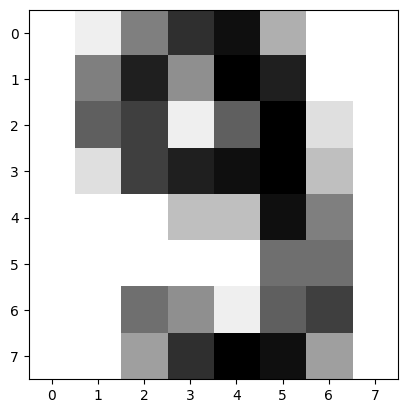

In [57]:
plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
y_pred = knn.predict([X_test[10]])
print(y_pred)

Logistic Regression

Logistic Regression: 0.975


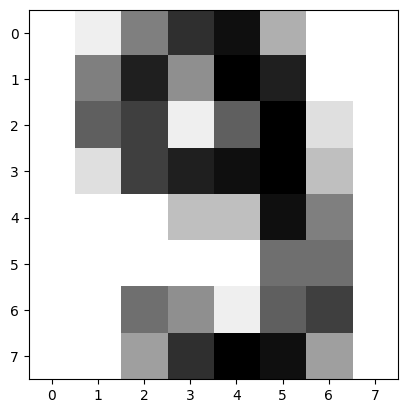

예측 결과: [9]
실제 정답: 9


In [58]:
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train, y_train)
logistic_score = metrics.accuracy_score(y_test, logistic.predict(X_test))

y_pred = logistic.predict(X_test)
score = metrics.accuracy_score(y_test, y_pred)
print("Logistic Regression:", score)

plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

y_pred = logistic.predict([X_test[10]])
print("예측 결과:", y_pred)
print("실제 정답:", y_test[10])

Decision Tree

Decision Tree: 0.8833333333333333


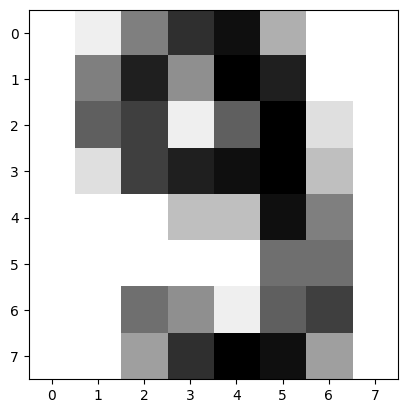

예측 결과: [9]
실제 정답: 9


In [59]:
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree_score = metrics.accuracy_score(y_test, tree.predict(X_test))

y_pred = tree.predict(X_test)
score = metrics.accuracy_score(y_test, y_pred)
print("Decision Tree:", score)

plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

y_pred = tree.predict([X_test[10]])
print("예측 결과:", y_pred)
print("실제 정답:", y_test[10])

Random Forest

Random Forest: 0.9805555555555555


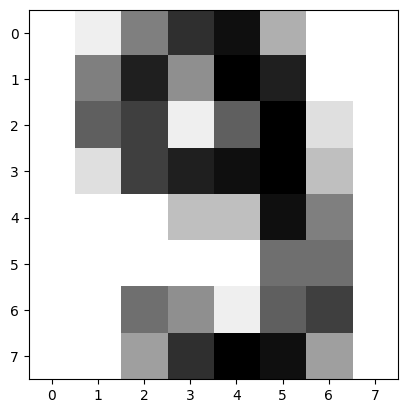

예측 결과: [9]
실제 정답: 9


In [60]:
forest = RandomForestClassifier(n_estimators=100)
forest.fit(X_train, y_train)
forest_score = metrics.accuracy_score(y_test, forest.predict(X_test))

y_pred = forest.predict(X_test)
score = metrics.accuracy_score(y_test, y_pred)
print("Random Forest:", score)

plt.imshow(X_test[10].reshape(8,8), cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

y_pred = forest.predict([X_test[10]])
print("예측 결과:", y_pred)
print("실제 정답:", y_test[10])

시각화

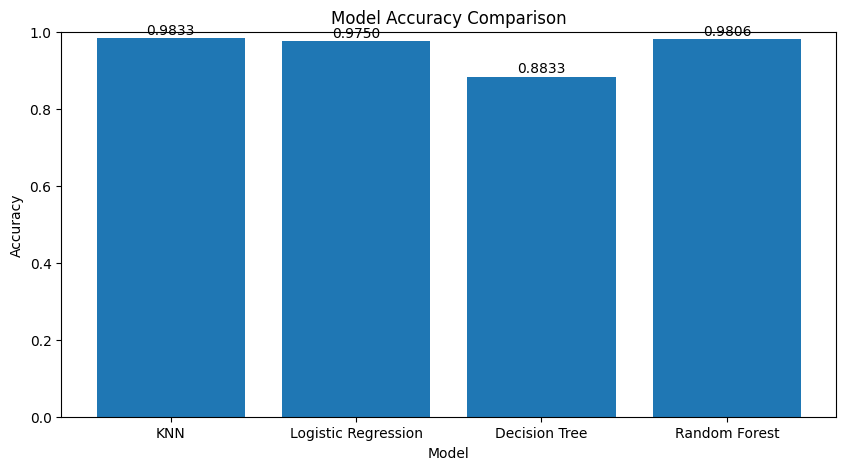

In [61]:
model_names = [
    "KNN",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

model_scores = [
    scores,
    logistic_score,
    tree_score,
    forest_score
]

plt.figure(figsize=(10, 5))

plt.bar(model_names, model_scores)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# 정확도 값 표시
for i, score in enumerate(model_scores):
    plt.text(i, score + 0.01, f"{score:.4f}",
             ha='center')

plt.show()